In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
df.shape

(400, 3)

In [5]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

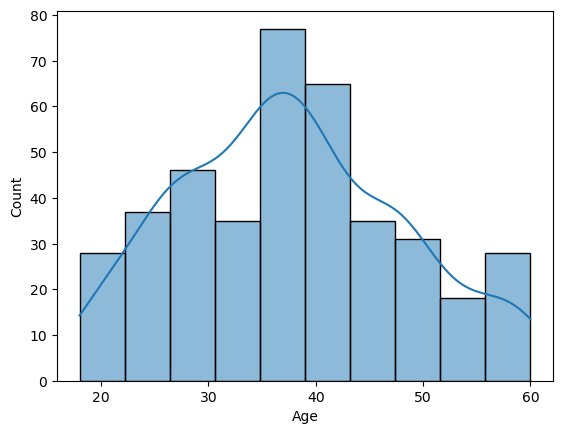

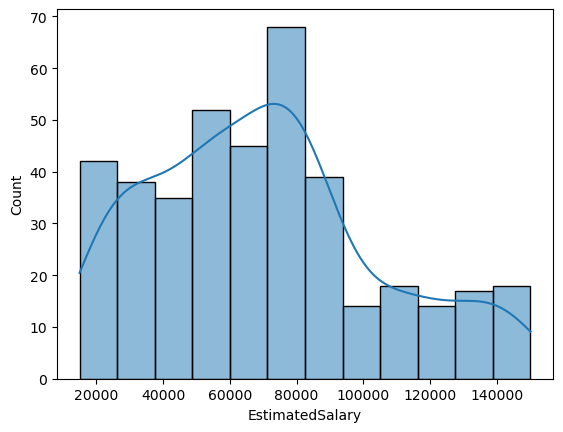

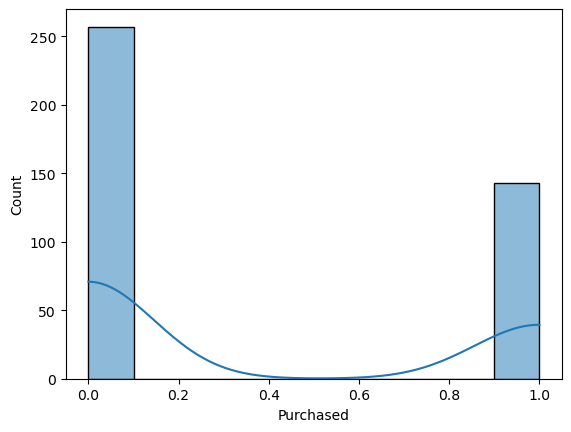

In [8]:
#Univariate Analysis
for i in df.columns:
     sb.histplot(df[i], kde=True)
     plt.show()

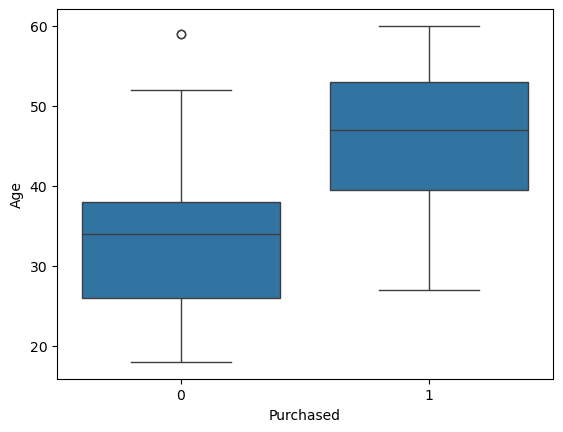

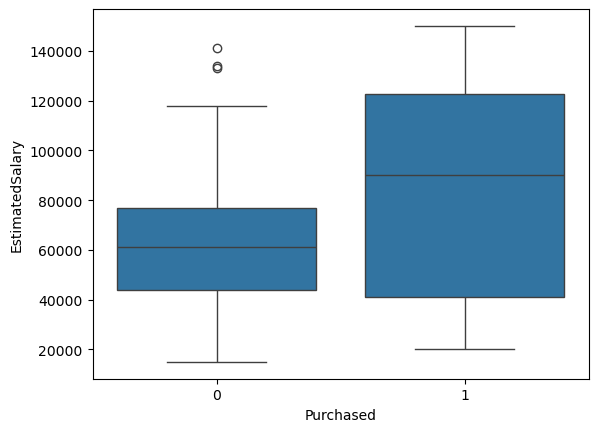

In [10]:
#Bivariate Analysis (column vs target)
sb.boxplot(x='Purchased', y='Age', data=df)
plt.show()
sb.boxplot(x='Purchased', y='EstimatedSalary', data=df)
plt.show()

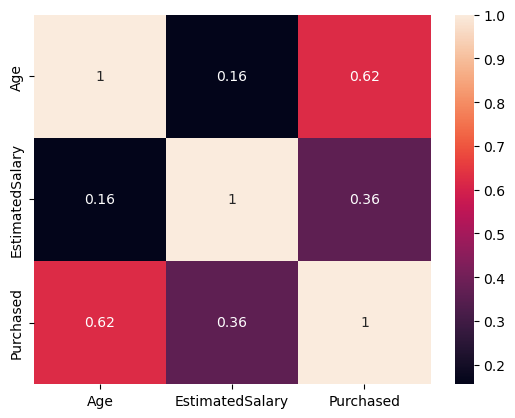

In [12]:
#Correlation Heatmap
sb.heatmap(df.corr(), annot=True)
plt.show()

In [13]:
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [15]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2)

In [18]:
sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

In [20]:
xtrain

array([[ 0.22402378,  1.083234  ],
       [ 0.70450374,  1.78221207],
       [-0.25645618, -0.89720389],
       [-0.64084015,  0.03476688],
       [ 0.12792779, -0.25647399],
       [-0.54474416,  1.89870842],
       [-1.02522412,  0.58812452],
       [-0.64084015, -0.05260538],
       [-1.12132011, -1.59618197],
       [-0.73693614,  0.50075226],
       [-1.12132011, -1.1010725 ],
       [-0.06426419,  0.12213914],
       [ 1.47327168,  2.13170111],
       [-0.25645618, -1.36318928],
       [ 1.37717569,  1.98608068],
       [ 2.04984763,  0.52987635],
       [ 0.41621577,  0.29688366],
       [-0.06426419,  0.06389096],
       [ 2.04984763,  0.38425592],
       [-1.69789606, -0.60596303],
       [-0.16036019, -0.28559807],
       [ 1.37717569, -0.92632798],
       [ 0.99279172,  0.12213914],
       [-1.69789606, -1.36318928],
       [-1.12132011,  0.32600774],
       [-0.54474416,  0.87936539],
       [ 0.80059973, -0.31472216],
       [ 1.08888771,  2.07345294],
       [ 0.99279172,

In [21]:
xtest

array([[ 0.80059973,  1.37447486],
       [ 0.99279172, -1.07194841],
       [-0.73693614,  1.083234  ],
       [ 0.89669573, -1.36318928],
       [ 1.76155966, -0.28559807],
       [ 0.41621577,  1.11235808],
       [-1.60180007,  0.52987635],
       [ 2.04984763,  0.18038731],
       [-1.2174161 , -1.07194841],
       [ 2.14594362, -0.80983163],
       [ 0.99279172,  1.86958433],
       [ 0.41621577,  0.26775957],
       [-0.16036019,  2.1608252 ],
       [-1.12132011,  0.29688366],
       [-0.92912812,  0.50075226],
       [ 1.08888771,  0.12213914],
       [-0.83303213, -0.6642112 ],
       [-0.25645618,  0.61724861],
       [ 2.14594362,  0.93761356],
       [ 0.0318318 , -0.31472216],
       [ 0.70450374, -1.39231337],
       [-0.06426419,  0.23863548],
       [-1.89008804,  0.35513183],
       [ 0.89669573, -0.78070755],
       [-0.54474416, -1.50880971],
       [-0.16036019, -0.19822581],
       [-0.73693614,  0.26775957],
       [ 0.51231176,  1.7239639 ],
       [-0.06426419,

In [22]:
svm_model = SVC(kernel='rbf')
svm_model.fit(xtrain, ytrain)

SVC()

In [23]:
svm_model.score(xtest, ytest)

0.925

In [24]:
#Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [26]:
ypred = svm_model.predict(xtest)

In [27]:
accuracy_score(ytest, ypred)

0.925

In [28]:
confusion_matrix(ytest, ypred)

array([[45,  4],
       [ 2, 29]], dtype=int64)

In [29]:
classification_report(ytest, ypred)

'              precision    recall  f1-score   support\n\n           0       0.96      0.92      0.94        49\n           1       0.88      0.94      0.91        31\n\n    accuracy                           0.93        80\n   macro avg       0.92      0.93      0.92        80\nweighted avg       0.93      0.93      0.93        80\n'